In [36]:
import pandas as pd
import numpy as np
df = pd.read_csv("kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [37]:
# Display structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [38]:
# Count missing values in each column
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [39]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [40]:
# Remove duplicate records if they exist
df.drop_duplicates(inplace=True)

In [41]:
# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

In [42]:
# Verify cleaned dataset
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [43]:
# Summary statistics for numerical columns
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631


In [44]:
#print mean values for numerical columns
print(df.mean(numeric_only=True))

id               4.580302e+09
price            5.400881e+05
bedrooms         3.370842e+00
bathrooms        2.114757e+00
sqft_living      2.079900e+03
sqft_lot         1.510697e+04
floors           1.494309e+00
waterfront       7.541757e-03
view             2.343034e-01
condition        3.409430e+00
grade            7.656873e+00
sqft_above       1.788391e+03
sqft_basement    2.915090e+02
yr_built         1.971005e+03
yr_renovated     8.440226e+01
zipcode          9.807794e+04
lat              4.756005e+01
long            -1.222139e+02
sqft_living15    1.986552e+03
sqft_lot15       1.276846e+04
dtype: float64


In [45]:
#print median values for numerical columns
print(df.median(numeric_only=True))

id               3.904930e+09
price            4.500000e+05
bedrooms         3.000000e+00
bathrooms        2.250000e+00
sqft_living      1.910000e+03
sqft_lot         7.618000e+03
floors           1.500000e+00
waterfront       0.000000e+00
view             0.000000e+00
condition        3.000000e+00
grade            7.000000e+00
sqft_above       1.560000e+03
sqft_basement    0.000000e+00
yr_built         1.975000e+03
yr_renovated     0.000000e+00
zipcode          9.806500e+04
lat              4.757180e+01
long            -1.222300e+02
sqft_living15    1.840000e+03
sqft_lot15       7.620000e+03
dtype: float64


In [46]:
#print mode values for numerical columns
print(df.mode().iloc[0])

id                       795000620.0
date             2014-06-23 00:00:00
price                       350000.0
bedrooms                         3.0
bathrooms                        2.5
sqft_living                   1300.0
sqft_lot                      5000.0
floors                           1.0
waterfront                       0.0
view                             0.0
condition                        3.0
grade                            7.0
sqft_above                    1300.0
sqft_basement                    0.0
yr_built                      2014.0
yr_renovated                     0.0
zipcode                      98103.0
lat                          47.5322
long                         -122.29
sqft_living15                 1540.0
sqft_lot15                    5000.0
Name: 0, dtype: object


In [47]:
#print standard deviation for numerical columns
print(df.std(numeric_only=True))

id               2.876566e+09
price            3.671272e+05
bedrooms         9.300618e-01
bathrooms        7.701632e-01
sqft_living      9.184409e+02
sqft_lot         4.142051e+04
floors           5.399889e-01
waterfront       8.651720e-02
view             7.663176e-01
condition        6.507430e-01
grade            1.175459e+00
sqft_above       8.280910e+02
sqft_basement    4.425750e+02
yr_built         2.937341e+01
yr_renovated     4.016792e+02
zipcode          5.350503e+01
lat              1.385637e-01
long             1.408283e-01
sqft_living15    6.853913e+02
sqft_lot15       2.730418e+04
dtype: float64


In [48]:
#print variance for numerical columns
print(df.var(numeric_only=True))

id               8.274629e+18
price            1.347824e+11
bedrooms         8.650150e-01
bathrooms        5.931513e-01
sqft_living      8.435337e+05
sqft_lot         1.715659e+09
floors           2.915880e-01
waterfront       7.485226e-03
view             5.872426e-01
condition        4.234665e-01
grade            1.381703e+00
sqft_above       6.857347e+05
sqft_basement    1.958727e+05
yr_built         8.627973e+02
yr_renovated     1.613462e+05
zipcode          2.862788e+03
lat              1.919990e-02
long             1.983262e-02
sqft_living15    4.697612e+05
sqft_lot15       7.455182e+08
dtype: float64


In [49]:
#print minimum and maximum values for numerical columns
print(df.min(numeric_only=True))
print(df.max(numeric_only=True))

id               1.000102e+06
price            7.500000e+04
bedrooms         0.000000e+00
bathrooms        0.000000e+00
sqft_living      2.900000e+02
sqft_lot         5.200000e+02
floors           1.000000e+00
waterfront       0.000000e+00
view             0.000000e+00
condition        1.000000e+00
grade            1.000000e+00
sqft_above       2.900000e+02
sqft_basement    0.000000e+00
yr_built         1.900000e+03
yr_renovated     0.000000e+00
zipcode          9.800100e+04
lat              4.715590e+01
long            -1.225190e+02
sqft_living15    3.990000e+02
sqft_lot15       6.510000e+02
dtype: float64
id               9.900000e+09
price            7.700000e+06
bedrooms         3.300000e+01
bathrooms        8.000000e+00
sqft_living      1.354000e+04
sqft_lot         1.651359e+06
floors           3.500000e+00
waterfront       1.000000e+00
view             4.000000e+00
condition        5.000000e+00
grade            1.300000e+01
sqft_above       9.410000e+03
sqft_basement    4.820000

In [50]:
#print Quartiles and IQR for Price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 321950.0
Q3: 645000.0
IQR: 323050.0


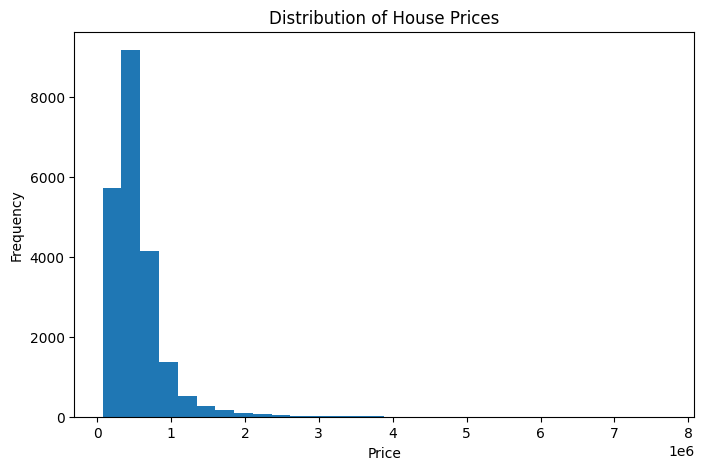

In [51]:
# Histogram showing the distribution of house prices
# identify common price ranges and skewness

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

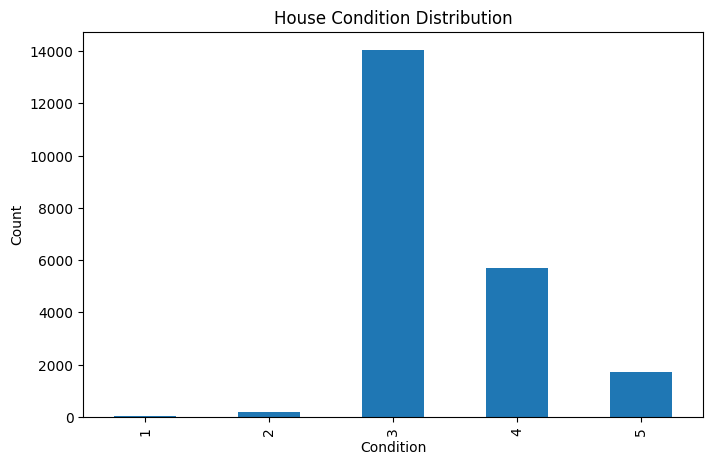

In [52]:
# Bar chart compareing the frequency of house conditions

plt.figure(figsize=(8,5))

df["condition"].value_counts().sort_index().plot(kind="bar")

plt.title("House Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")

plt.show()

In [53]:
# The bar chart shows that most houses are in average condition,
# while very poor and excellent conditions are lesser than average.

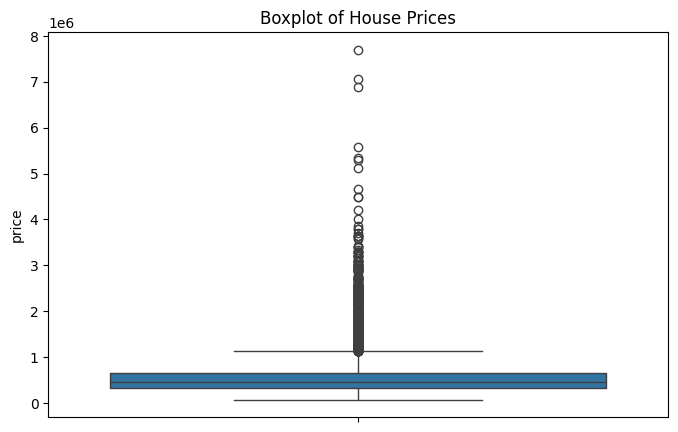

In [54]:
# Boxplot identifying outliers in house prices

import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(y=df["price"])

plt.title("Boxplot of House Prices")

plt.show()

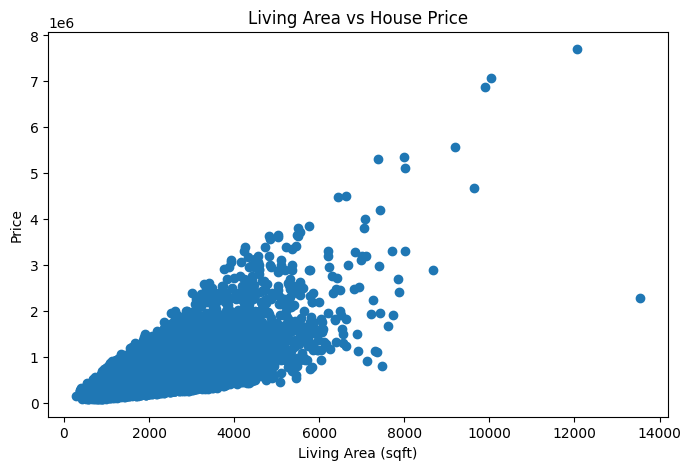

In [55]:
# Scatter plot examining the relationship between living area and house price

plt.figure(figsize=(8,5))

plt.scatter(
    df["sqft_living"],
    df["price"]
)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")

plt.show()

In [56]:
# It shows that Houses with larger living areas generally tend to have higher prices.

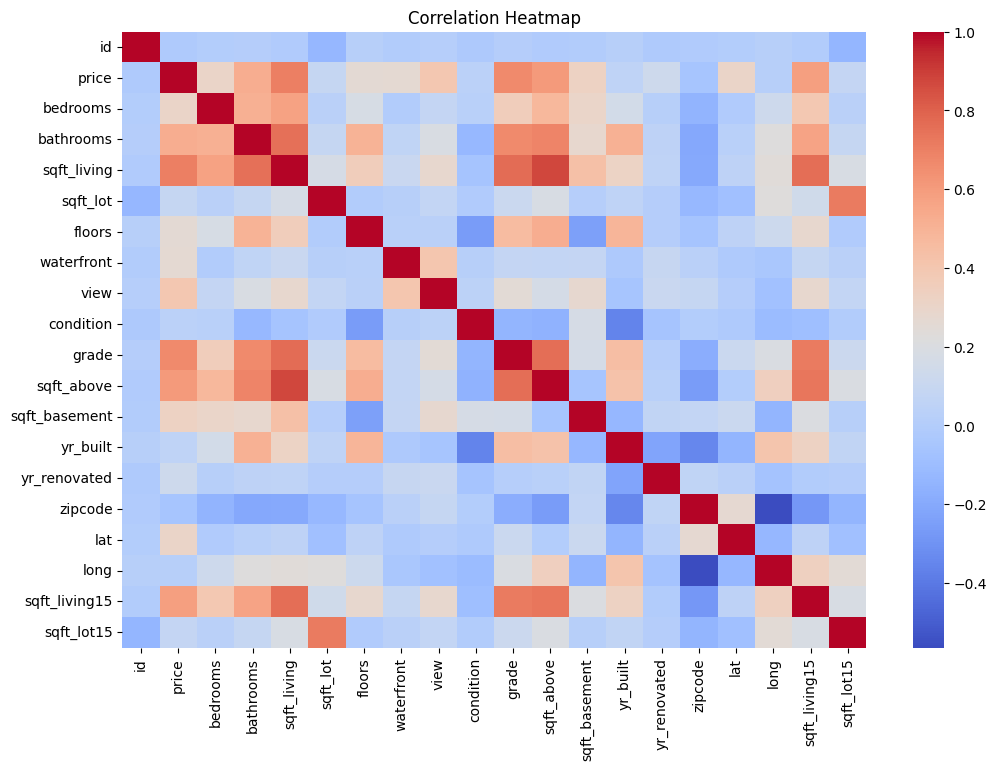

In [57]:
# Heatmap showing relationships among numerical variables

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [58]:
# Strong positive correlations indicate variables that strongly influence the house prices.

In [59]:
# Does the living area (sqft_living) significantly affect house price?

In [60]:
# Hypotheses

# H₀ (Null Hypothesis)

# There is no significant relationship between house price and living area (sqft_living).

# H₁ (Alternative Hypothesis)

# There is a significant relationship between house price and living area (sqft_living).

In [61]:
from scipy import stats

correlation, p_value = stats.pearsonr(
    df["sqft_living"],
    df["price"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.7020350546118002
P-value: 0.0


In [62]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [63]:
# A Pearson Correlation Test was conducted to determine whether there is a significant relationship between the living area of a house (sqft_living) and its price.
# The correlation coefficient was 0.702, indicating a strong positive relationship between the two variables. 
# The p-value was 0.000, which is less than the significance level of 0.05. Therefore, the Null Hypothesis (H₀) is rejected and the Alternative Hypothesis (H₁) is accepted.
# This result indicates that there is a statistically significant positive relationship between living area and house price.
# In general, houses with larger living areas tend to have higher prices.